In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sohailkhan05/house-price-prediction-advanced-regression/house_price_prediction_advanced_regression.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("/kaggle/input/datasets/sohailkhan05/house-price-prediction-advanced-regression/house_price_prediction_advanced_regression.csv")
df = pd.DataFrame(data)
df.head()

,property_id,country,property_type,condition,bedrooms,bathrooms,floors,parking_spots,built_year,city,...,noise_5,noise_6,noise_7,noise_8,noise_9,noise_10,noise_11,noise_12,noise_13,noise_14
0,467853,UK,Villa,Luxury,1,2,3,3,1999,Birmingham,...,0.041490,0.903970,0.248306,0.652978,-0.543277,-0.757071,0.286868,-1.101469,-0.631376,0.548008
1,401997,Spain,Apartment,new,9,4,1,1,1982,Madrid,...,0.405441,-0.697392,-0.890734,2.024623,0.078306,1.398118,-0.326767,2.904358,-0.666788,0.126283
2,88436,Brazil,Apartment,Renovated,4,5,2,3,1957,Sao Paulo,...,-0.301511,0.131955,-0.976636,0.229704,1.358533,0.527816,-0.051949,1.541304,-0.009346,-0.129739
3,33855,Germany,Townhouse,Old,10,6,3,1,1967,Berlin,...,-0.234412,0.680395,-1.927466,0.496797,1.293100,1.018163,-1.218271,0.074830,1.012906,1.803595
4,222142,Canada,Penthouse,Old,7,6,2,0,1977,Montreal,...,-0.111238,1.638835,0.072931,-0.399528,-0.028257,-0.863598,-0.017557,-1.234406,0.019719,-1.259738


In [4]:
df.shape

(515000, 46)

In [5]:
df.columns

Index(['property_id', 'country', 'property_type', 'condition', 'bedrooms',
       'bathrooms', 'floors', 'parking_spots', 'built_year', 'city',
       'total_area', 'land_area', 'latitude', 'longitude', 'district',
       'postal_code', 'listing_date', 'interest_rate', 'inflation_index',
       'housing_index', 'luxury_demand_index', 'final_sale_price',
       'listing_price', 'price_per_sqm', 'currency', 'hoa_fee', 'property_tax',
       'days_on_market', 'price_revision_count', 'title', 'description',
       'noise_0', 'noise_1', 'noise_2', 'noise_3', 'noise_4', 'noise_5',
       'noise_6', 'noise_7', 'noise_8', 'noise_9', 'noise_10', 'noise_11',
       'noise_12', 'noise_13', 'noise_14'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515000 entries, 0 to 514999
Data columns (total 46 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   property_id           515000 non-null  int64  
 1   country               515000 non-null  object 
 2   property_type         515000 non-null  object 
 3   condition             515000 non-null  object 
 4   bedrooms              515000 non-null  int64  
 5   bathrooms             515000 non-null  int64  
 6   floors                515000 non-null  int64  
 7   parking_spots         515000 non-null  int64  
 8   built_year            515000 non-null  int64  
 9   city                  515000 non-null  object 
 10  total_area            515000 non-null  float64
 11  land_area             515000 non-null  float64
 12  latitude              515000 non-null  float64
 13  longitude             515000 non-null  float64
 14  district              515000 non-null  object 
 15  

In [7]:
col = ['property_id', 'country', 'property_type', 'condition', 'bedrooms',
       'bathrooms', 'floors', 'parking_spots', 'built_year', 'city',
       'total_area', 'land_area', 'latitude', 'longitude', 'district',
       'postal_code', 'listing_date', 'interest_rate', 'inflation_index',
       'housing_index', 'luxury_demand_index', 'final_sale_price',
       'listing_price', 'price_per_sqm', 'currency', 'hoa_fee', 'property_tax',
       'days_on_market', 'price_revision_count', 'title', 'description',
       'noise_0', 'noise_1', 'noise_2', 'noise_3', 'noise_4', 'noise_5',
       'noise_6', 'noise_7', 'noise_8', 'noise_9', 'noise_10', 'noise_11',
       'noise_12', 'noise_13', 'noise_14']
for cols in col:
    print(df[cols].head())

0    467853
1    401997
2     88436
3     33855
4    222142
Name: property_id, dtype: int64
0         UK
1      Spain
2     Brazil
3    Germany
4     Canada
Name: country, dtype: object
0        Villa
1    Apartment
2    Apartment
3    Townhouse
4    Penthouse
Name: property_type, dtype: object
0       Luxury
1          new
2    Renovated
3          Old
4          Old
Name: condition, dtype: object
0     1
1     9
2     4
3    10
4     7
Name: bedrooms, dtype: int64
0    2
1    4
2    5
3    6
4    6
Name: bathrooms, dtype: int64
0    3
1    1
2    2
3    3
4    2
Name: floors, dtype: int64
0    3
1    1
2    3
3    1
4    0
Name: parking_spots, dtype: int64
0    1999
1    1982
2    1957
3    1967
4    1977
Name: built_year, dtype: int64
0    Birmingham
1        Madrid
2     Sao Paulo
3        Berlin
4      Montreal
Name: city, dtype: object
0    107.259397
1    109.536126
2     34.497487
3     93.441801
4    393.361466
Name: total_area, dtype: float64
0    244.287460
1    260.826392
2

In [8]:
df.isnull().sum()

property_id             0
country                 0
property_type           0
condition               0
bedrooms                0
bathrooms               0
floors                  0
parking_spots           0
built_year              0
city                    0
total_area              0
land_area               0
latitude                0
longitude               0
district                0
postal_code             0
listing_date            0
interest_rate           0
inflation_index         0
housing_index           0
luxury_demand_index     0
final_sale_price        0
listing_price           0
price_per_sqm           0
currency                0
hoa_fee                 0
property_tax            0
days_on_market          0
price_revision_count    0
title                   0
description             0
noise_0                 0
noise_1                 0
noise_2                 0
noise_3                 0
noise_4                 0
noise_5                 0
noise_6                 0
noise_7     

In [9]:
df[df.duplicated()].head(10)

,property_id,country,property_type,condition,bedrooms,bathrooms,floors,parking_spots,built_year,city,...,noise_5,noise_6,noise_7,noise_8,noise_9,noise_10,noise_11,noise_12,noise_13,noise_14
4170,367736,Brazil,Apartment,New,10,3,1,2,1997,São Paulo,...,1.552604,-1.231948,-2.501993,0.832255,1.377510,-1.702447,-0.011848,0.870787,-0.593413,-0.885096
5782,326455,Spain,Studio,Under Construction,10,5,4,0,1993,Barcelona,...,2.002230,-0.485534,0.346587,0.942155,1.814336,0.048351,0.107084,0.186254,-0.222952,0.261209
6392,488023,Spain,Villa,New,1,1,2,1,1957,Barcelona,...,1.315410,0.118766,2.240789,-0.160233,0.701074,-0.199877,-1.535130,-1.539164,0.051010,1.949843
6920,416623,France,Villa,Needs Repair,3,3,3,3,1981,Paris,...,-1.282058,-2.615102,-1.195431,0.452326,-0.107367,0.938915,0.446014,-1.365394,1.032359,-0.215769
8010,273233,UK,Townhouse,new,9,2,4,3,1967,Birmingham,...,1.867305,-0.056433,0.022666,-2.437659,-1.436910,0.748226,-0.848677,-0.408962,-0.374344,2.965575
10172,293165,Spain,Villa,New,0,7,1,1,1996,Barcelona,...,1.133405,-0.587012,-1.388433,0.061398,-0.317398,1.519839,-0.074821,1.842263,1.804774,1.979227
10276,334165,Brazil,Villa,Renovated,7,1,3,3,1994,São Paulo,...,0.828058,-0.779130,-0.103450,-1.917983,0.508124,-0.973486,0.173460,0.722395,-2.026593,-0.730138
11295,455773,Australia,Condo,Luxury,11,2,4,0,1974,Brisbane,...,0.221043,-2.739623,-0.793373,0.868592,-1.644321,2.082419,1.223850,-1.096705,1.133416,0.424804
12101,467853,UK,Villa,Luxury,1,2,3,3,1999,Birmingham,...,0.041490,0.903970,0.248306,0.652978,-0.543277,-0.757071,0.286868,-1.101469,-0.631376,0.548008
12982,308022,Canada,Apartment,Under Construction,11,6,2,2,2009,Montreal,...,0.612852,0.531402,-0.496118,0.261058,-2.001818,1.880823,0.674590,0.225360,0.000388,0.758868


In [10]:
# 'District_435' this is district value and object dtype and as district is same throughtout this whole column , i would suggest to remove district and only put numbers here and change dtype from object to int.

# EDA

In [11]:
df.describe()

,property_id,bedrooms,bathrooms,floors,parking_spots,built_year,total_area,land_area,latitude,longitude,...,noise_5,noise_6,noise_7,noise_8,noise_9,noise_10,noise_11,noise_12,noise_13,noise_14
count,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,...,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000,515000.000000
mean,249993.636066,5.503575,4.001695,2.500423,1.500528,1986.518041,565.668259,299.862578,-0.019391,-0.027405,...,0.003642,-0.001517,0.002930,-0.001614,0.000953,-0.001076,-0.000404,0.000205,0.001031,0.001831
std,144323.976267,3.452535,2.001683,1.118018,1.117430,21.355428,935.783495,236.470986,34.613436,86.631598,...,0.998681,1.000691,0.998574,1.001264,0.997501,0.999705,1.000402,1.000056,0.999926,0.998497
min,0.000000,0.000000,1.000000,1.000000,0.000000,1950.000000,-8370.764690,0.193698,-59.999821,-149.999783,...,-4.833167,-4.993069,-5.328562,-4.812680,-4.707785,-4.485990,-4.758258,-4.616214,-4.546697,-4.713989
25%,125015.750000,3.000000,2.000000,1.000000,1.000000,1968.000000,89.055486,131.292140,-30.032498,-75.161649,...,-0.669884,-0.675603,-0.668681,-0.676867,-0.672237,-0.677372,-0.674682,-0.672915,-0.674001,-0.672158
50%,249976.500000,6.000000,4.000000,3.000000,2.000000,1987.000000,179.695938,237.944546,0.031043,0.124559,...,0.004318,-0.002145,0.004436,-0.001739,0.001141,-0.000756,-0.001505,0.000821,0.000754,0.001657
75%,374982.250000,9.000000,6.000000,3.000000,2.000000,2005.000000,573.213408,401.430047,29.893220,74.864652,...,0.678685,0.672073,0.675303,0.673239,0.675031,0.672160,0.675023,0.674930,0.676208,0.674830
max,499999.000000,11.000000,7.000000,4.000000,3.000000,2023.000000,12657.317961,2529.913510,59.999990,149.999707,...,4.657584,4.626881,4.620889,4.480445,5.456263,4.852484,4.729143,4.656799,5.079031,4.370983


# univariate numerical

In [12]:
numeric_df = df.select_dtypes(include="number")
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols


['property_id',
 'bedrooms',
 'bathrooms',
 'floors',
 'parking_spots',
 'built_year',
 'total_area',
 'land_area',
 'latitude',
 'longitude',
 'postal_code',
 'interest_rate',
 'inflation_index',
 'housing_index',
 'luxury_demand_index',
 'final_sale_price',
 'price_per_sqm',
 'property_tax',
 'days_on_market',
 'price_revision_count',
 'noise_0',
 'noise_1',
 'noise_2',
 'noise_3',
 'noise_4',
 'noise_5',
 'noise_6',
 'noise_7',
 'noise_8',
 'noise_9',
 'noise_10',
 'noise_11',
 'noise_12',
 'noise_13',
 'noise_14']

In [13]:
# for col in numeric_cols:
#     plt.figure(figsize=(8,4))
#     plt.title(f"kde plot for {col}")
#     df[col].plot(kind="kde")
#     plt.show()

In [14]:
# numeric_cols
# for col in numeric_cols:
#     plt.figure(figsize=(8,4))
#     plt.title(f"histogram plot for {col}")
#     df[col].plot(kind="hist",bins=20)
#     plt.show()
    

In [15]:
 # for col in numeric_cols:
 #     plt.figure(figsize=(8,4))
 #     plt.title(f"box plot for {col}")
 #     df[col].plot(kind="box")
 #     plt.show()

# conclusion
Numerical EDA revealed discrete/count variables, right-skewed continuous variables, several outliers, physically invalid values in total_area, substantially different feature scales, and potentially suspicious values in price-related features. These issues require further investigation before preprocessing and modeling.

# categorical univariate

In [16]:
cat_df = df.select_dtypes(include="object")
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols

['country',
 'property_type',
 'condition',
 'city',
 'district',
 'listing_date',
 'listing_price',
 'currency',
 'hoa_fee',
 'title',
 'description']

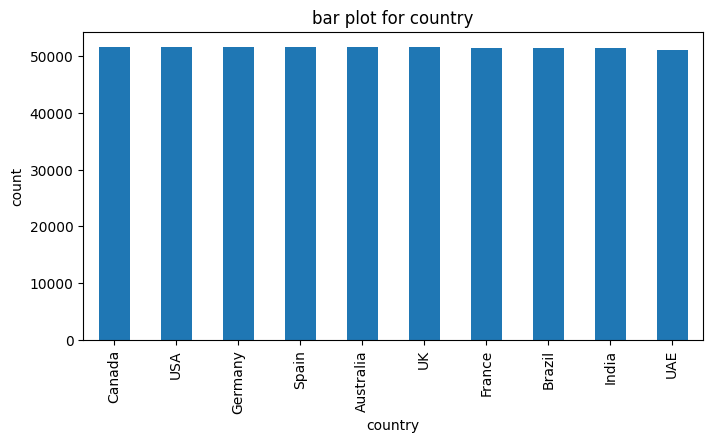

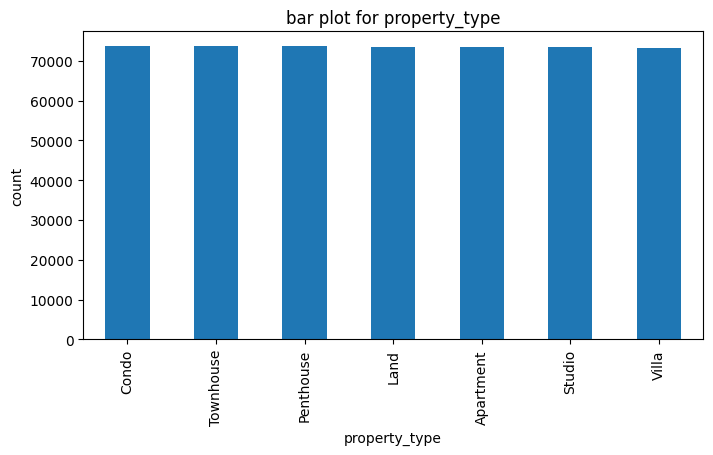

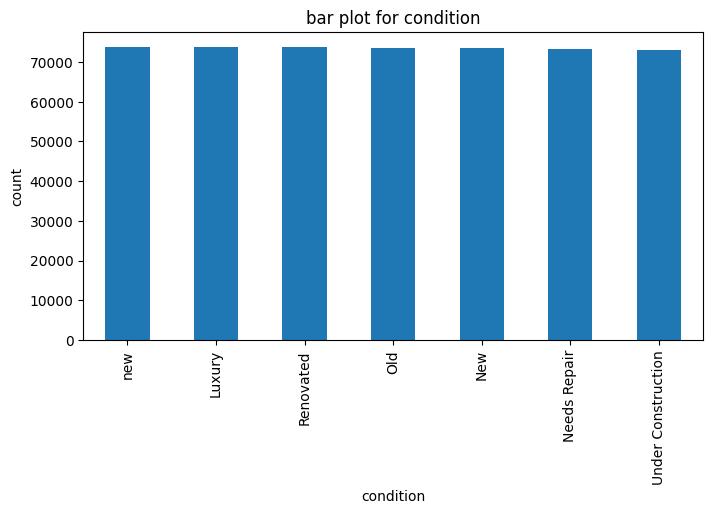

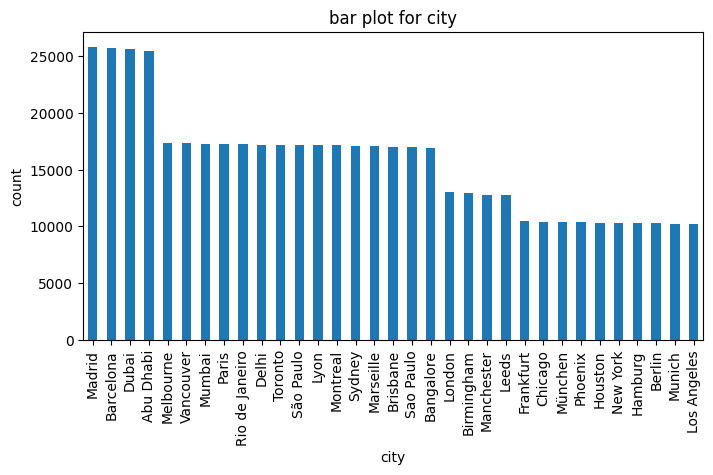

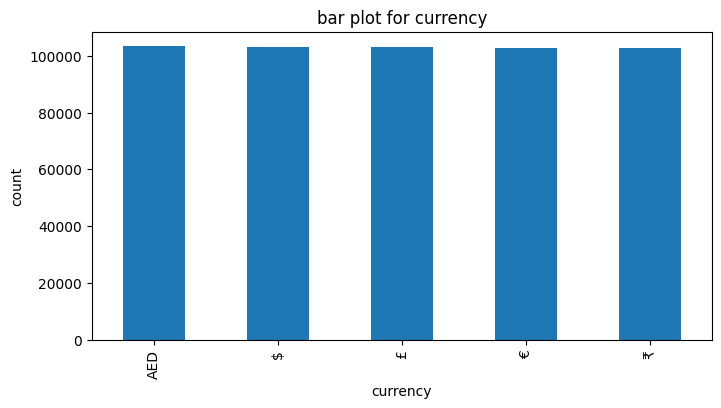

In [17]:
small_cat = ["country","property_type","condition","city","currency"]
for col in small_cat:
    plt.figure(figsize=(8,4))
    df[col].value_counts().plot(kind="bar")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.title(f"bar plot for {col}")
    plt.show()

In [18]:
for col in cat_cols:
    print(df[col].value_counts())

country
Canada       51670
USA          51624
Germany      51615
Spain        51575
Australia    51552
UK           51497
France       51458
Brazil       51447
India        51433
UAE          51129
Name: count, dtype: int64
property_type
Condo        73731
Townhouse    73705
Penthouse    73620
Land         73559
Apartment    73547
Studio       73547
Villa        73291
Name: count, dtype: int64
condition
new                   73881
Luxury                73748
Renovated             73748
Old                   73598
New                   73550
Needs Repair          73376
Under Construction    73099
Name: count, dtype: int64
city
Madrid            25863
Barcelona         25712
Dubai             25644
Abu Dhabi         25485
Melbourne         17383
Vancouver         17329
Mumbai            17276
Paris             17245
Rio de Janeiro    17229
Delhi             17200
Toronto           17198
São Paulo         17183
Lyon              17164
Montreal          17143
Sydney            17132
Marsei

<Axes: xlabel='district'>

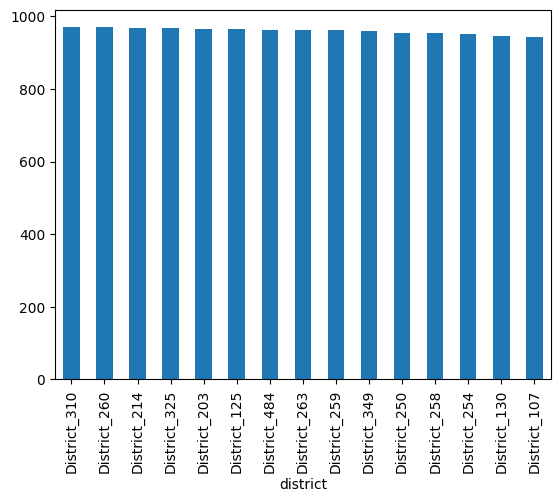

In [19]:
df["district"].nunique()
# df["district"].value_counts().head(15).plot(kind="bar")
df["district"].value_counts().tail(15).plot(kind="bar")


<Axes: xlabel='city'>

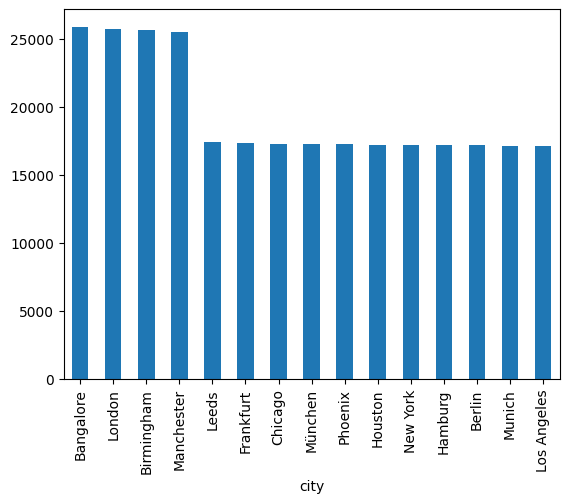

In [20]:
df["city"].nunique()
df["city"].value_counts().head(15).plot(kind="bar")
df["city"].value_counts().tail(15).plot(kind="bar")


<Axes: xlabel='hoa_fee'>

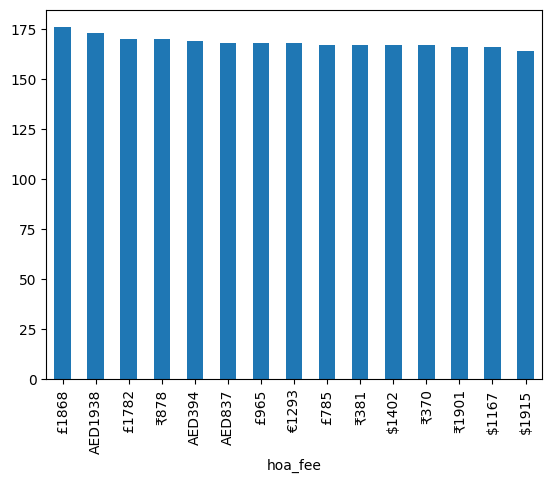

In [21]:
df["hoa_fee"].nunique()
df["hoa_fee"].value_counts().head(15).plot(kind="bar")
df["hoa_fee"].value_counts().tail(15).plot(kind="bar")

<Axes: xlabel='listing_price'>

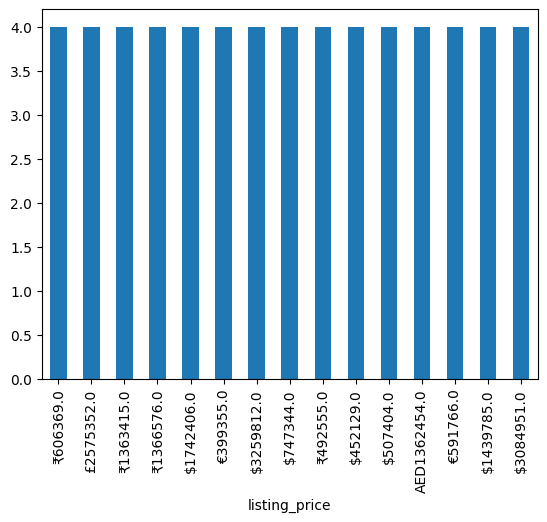

In [22]:
df["listing_price"].nunique()
df["listing_price"].value_counts().head(15).plot(kind="bar")
df["listing_price"].value_counts().tail(15).plot(kind="bar")

# conclusion
Categorical EDA revealed mostly balanced low-cardinality features, while city, district, and postal_code require special handling due to higher cardinality. postal_code is categorical despite its integer dtype, while listing_date is a datetime feature and title/description are text features excluded from this regression project.

# Numerical Bivariate

In [ ]:
numeric_cols
half_col=[
 'built_year',
 'total_area',
 'land_area',
 'latitude',
 'longitude',
 'postal_code',
 'interest_rate',
 'inflation_index',
 'housing_index',
 'luxury_demand_index',
 'final_sale_price',
 'price_per_sqm',
 'property_tax',
 'days_on_market',
 'price_revision_count']

other_col=['property_id',
 'bedrooms',
 'bathrooms',
 'floors',
 'parking_spots']

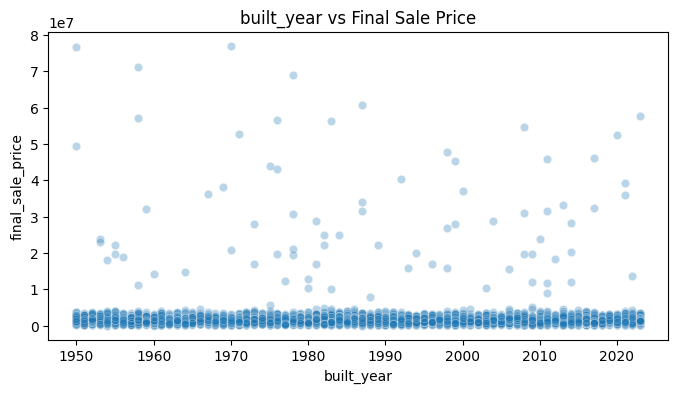

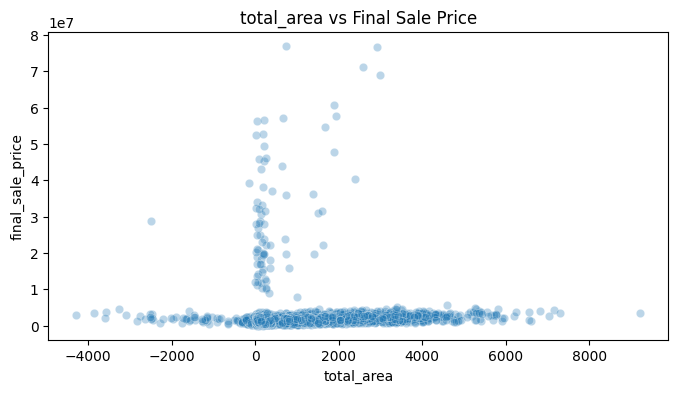

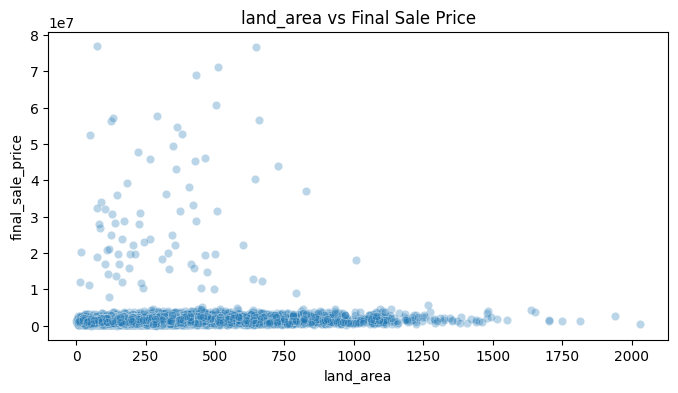

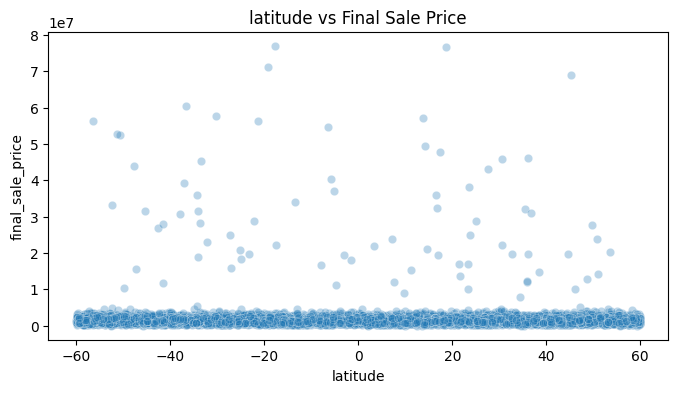

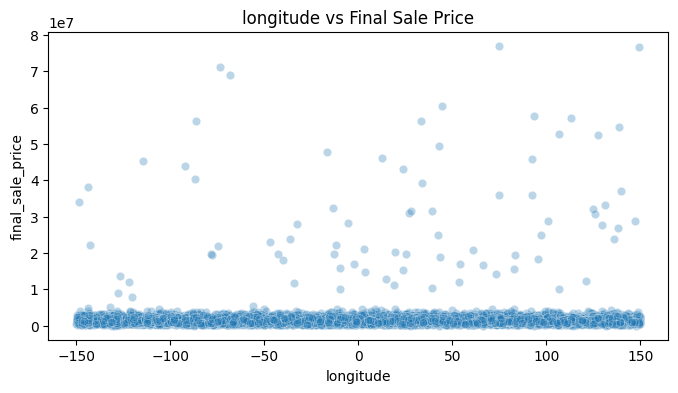

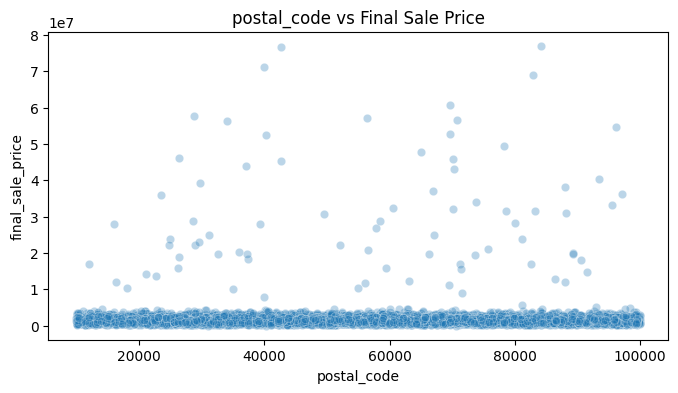

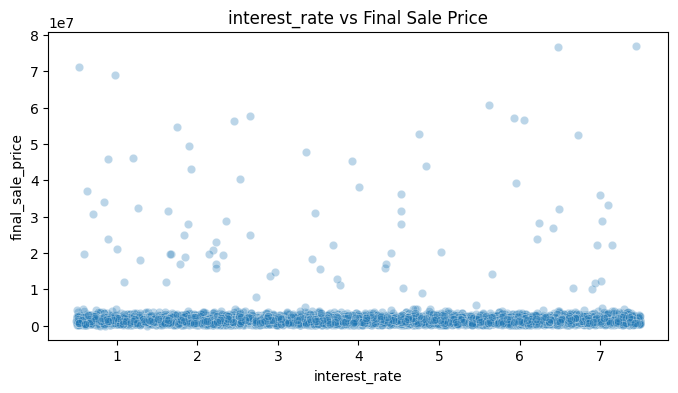

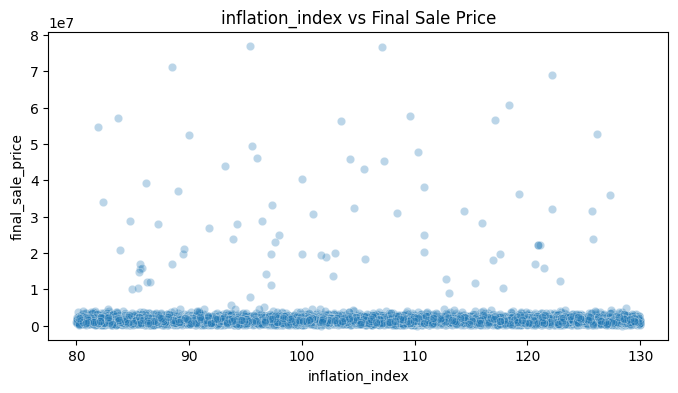

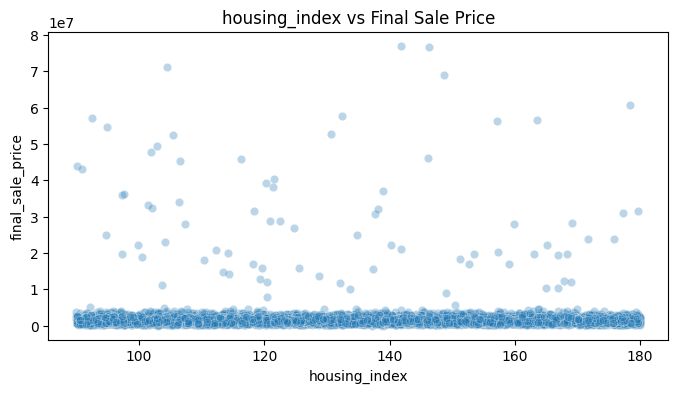

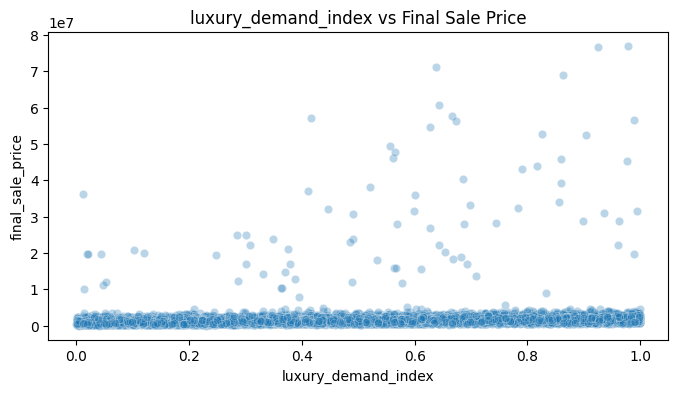

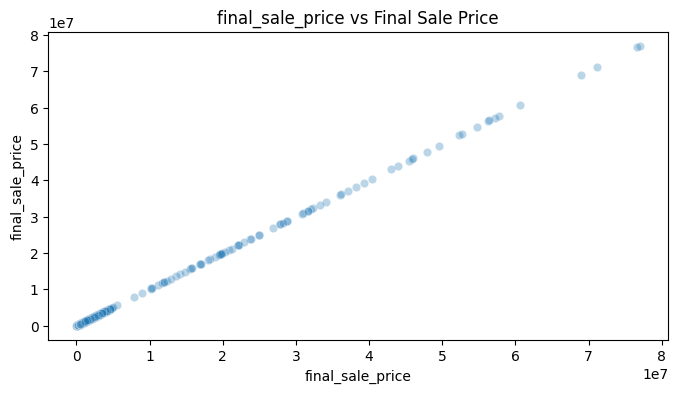

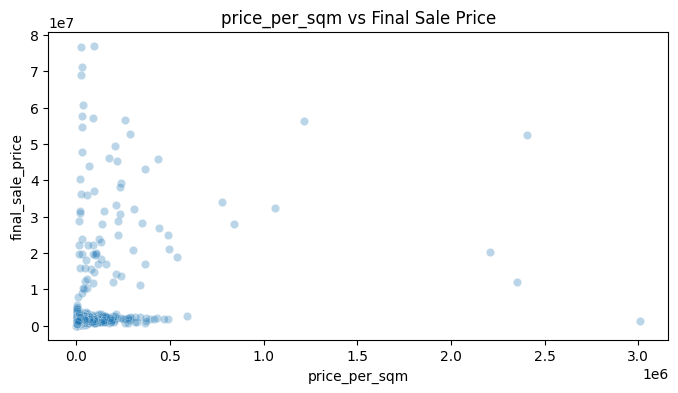

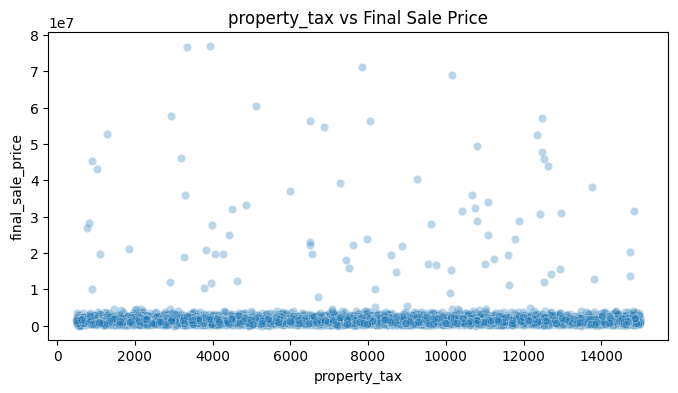

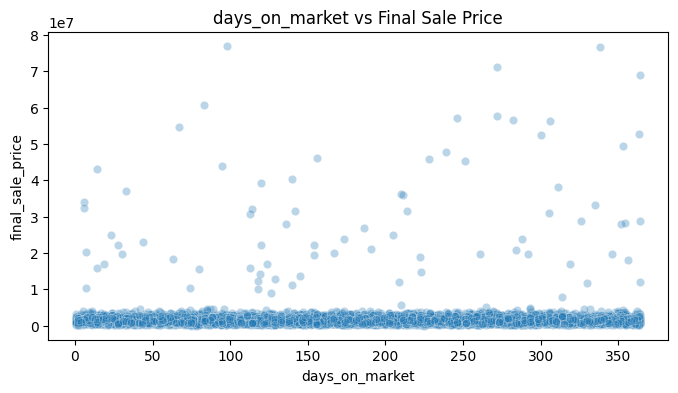

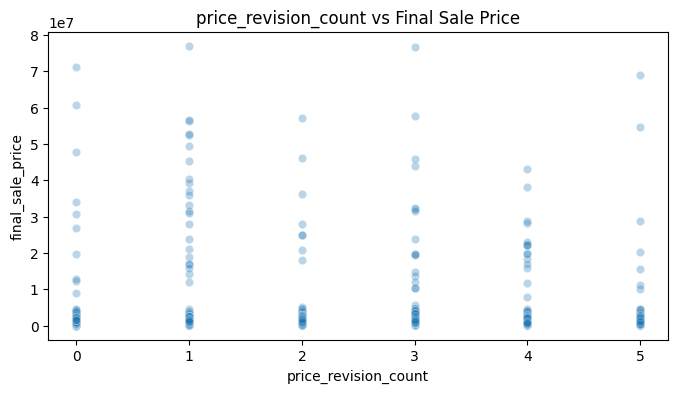

In [30]:
sample = df.sample(10000, random_state=42)

for col in half_col:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(
        x=col,
        y="final_sale_price",
        data=sample,
        alpha=0.3
    )
    plt.title(f"{col} vs Final Sale Price")
    plt.show()

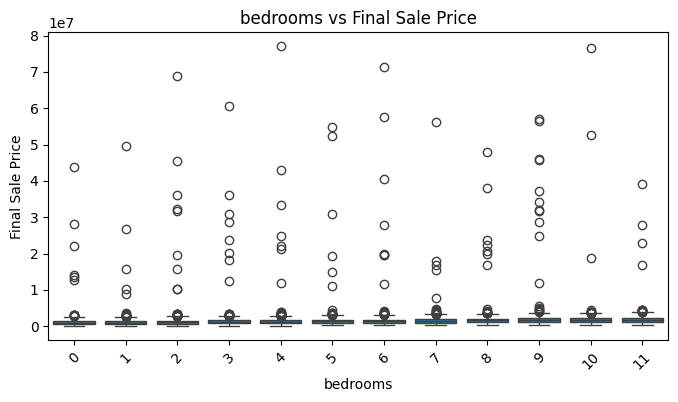

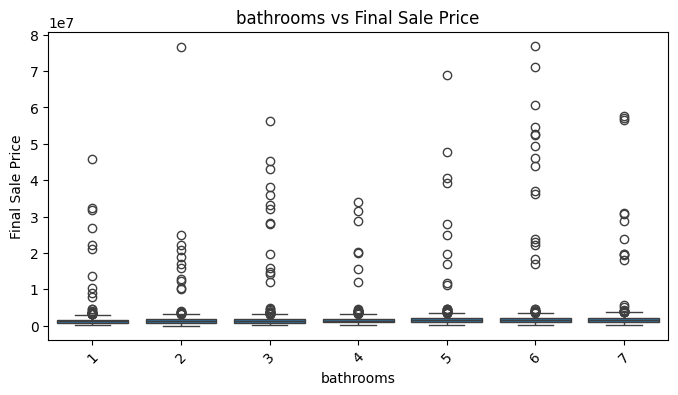

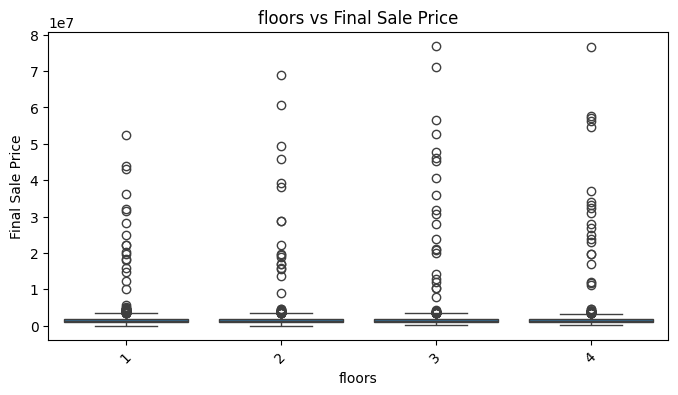

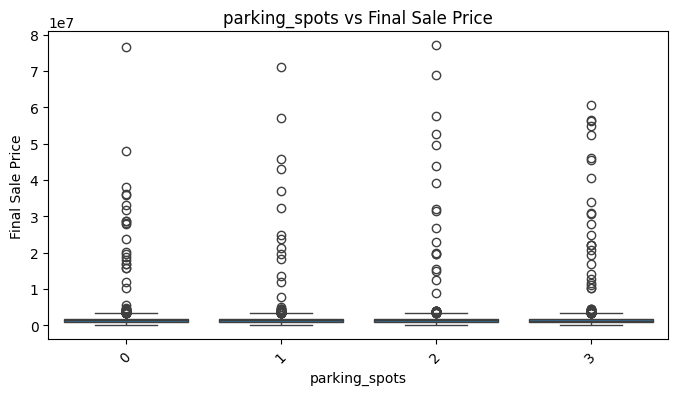

In [32]:
sample = df.sample(10000, random_state=42)

for col in other_col:
    if col == "property_id":
        continue

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=sample,
        x=col,
        y="final_sale_price"
    )

    plt.title(f"{col} vs Final Sale Price")
    plt.xlabel(col)
    plt.ylabel("Final Sale Price")
    plt.xticks(rotation=45)
    plt.show()